In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

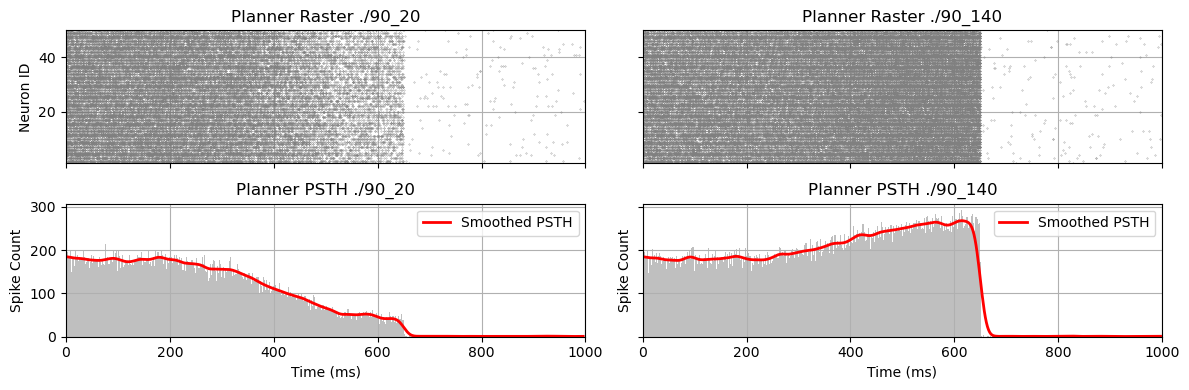

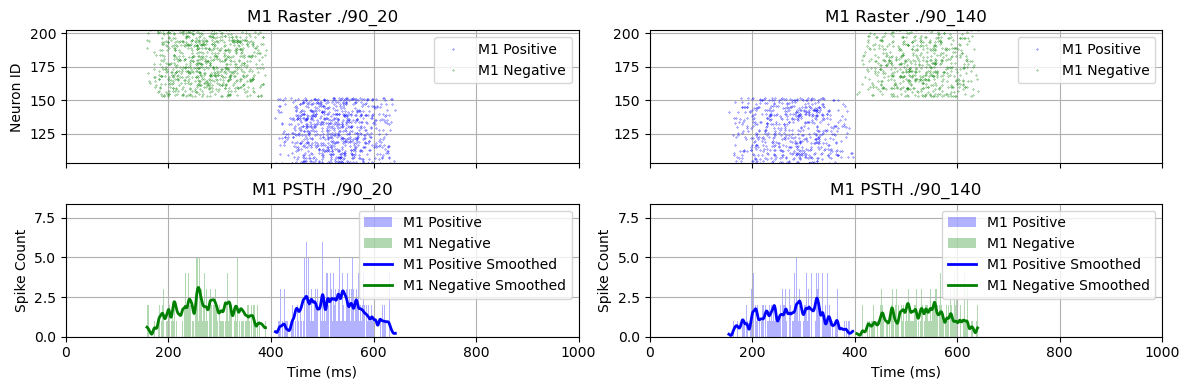

In [5]:
# Load spiking data from the planner output (.dat file) for both folders
planner_filename_20 = './90_20/planner_p-101-0.dat'
planner_spiking_data_20 = pd.read_csv(
    planner_filename_20,
    sep='\t',
    comment='#'
)
planner_filename_140 = './90_140/planner_p-101-0.dat'
planner_spiking_data_140 = pd.read_csv(
    planner_filename_140,
    sep='\t',
    comment='#'
)

# Load M1 spiking data for both folders
pos_filename_20 = './90_20/mc_m1_p-203-0.dat'
posM1_spiking_data_20 = pd.read_csv(
    pos_filename_20,
    sep='\t',
    comment='#'
)
neg_filename_20 = './90_20/mc_m1_n-204-0.dat'
negM1_spiking_data_20 = pd.read_csv(
    neg_filename_20,
    sep='\t',
    comment='#'
)
pos_filename_140 = './90_140/mc_m1_p-203-0.dat'
posM1_spiking_data_140 = pd.read_csv(
    pos_filename_140,
    sep='\t',
    comment='#'
)
neg_filename_140 = './90_140/mc_m1_n-204-0.dat'
negM1_spiking_data_140 = pd.read_csv(
    neg_filename_140,
    sep='\t',
    comment='#'
)

# --- Create 2-column grid for planner plots ---
fig, axs = plt.subplots(2, 2, figsize=(12, 4), sharex='col', sharey='row')

# Raster plot for planner (left column: ./90_20, right column: ./90_140)
axs[0,0].set_title('Planner Raster ./90_20')
axs[0,0].plot(planner_spiking_data_20['time_ms'], planner_spiking_data_20['sender'], '.', markersize=0.5, color='gray')
axs[0,0].set_ylabel('Neuron ID')
axs[0,0].set_xlim(0, 1000.0)
axs[0,0].set_ylim(planner_spiking_data_20['sender'].min(), planner_spiking_data_20['sender'].max())
axs[0,0].grid(True)

axs[0,1].set_title('Planner Raster ./90_140')
axs[0,1].plot(planner_spiking_data_140['time_ms'], planner_spiking_data_140['sender'], '.', markersize=0.5, color='gray')
axs[0,1].set_xlim(0, 1000.0)
axs[0,1].set_ylim(planner_spiking_data_140['sender'].min(), planner_spiking_data_140['sender'].max())
axs[0,1].grid(True)

# PSTH for planner (left column: ./90_20, right column: ./90_140)
axs[1,0].set_title('Planner PSTH ./90_20')
bins = 500
counts_planner_20, bins_planner_20, _ = axs[1,0].hist(planner_spiking_data_20['time_ms'], bins=bins, color='gray', alpha=0.5)
smoothed_planner_20 = gaussian_filter1d(counts_planner_20, sigma=5)
bin_centers_20 = (bins_planner_20[:-1] + bins_planner_20[1:]) / 2
axs[1,0].plot(bin_centers_20, smoothed_planner_20, color='red', linewidth=2, label='Smoothed PSTH')
axs[1,0].set_xlabel('Time (ms)')
axs[1,0].set_ylabel('Spike Count')
axs[1,0].set_xlim(0, 1000.0)
axs[1,0].grid(True)
axs[1,0].legend()

axs[1,1].set_title('Planner PSTH ./90_140')
counts_planner_140, bins_planner_140, _ = axs[1,1].hist(planner_spiking_data_140['time_ms'], bins=bins, color='gray', alpha=0.5)
smoothed_planner_140 = gaussian_filter1d(counts_planner_140, sigma=5)
bin_centers_140 = (bins_planner_140[:-1] + bins_planner_140[1:]) / 2
axs[1,1].plot(bin_centers_140, smoothed_planner_140, color='red', linewidth=2, label='Smoothed PSTH')
axs[1,1].set_xlabel('Time (ms)')
axs[1,1].set_ylabel('Spike Count')
axs[1,1].set_xlim(0, 1000.0)
axs[1,1].grid(True)
axs[1,1].legend()
plt.tight_layout()

# --- Create 2-column grid for M1 plots ---
fig, axs = plt.subplots(2, 2, figsize=(12, 4), sharex='col')

# Raster plot for M1 pos/neg (left column: ./90_20, right column: ./90_140)
axs[0,0].set_title('M1 Raster ./90_20')
axs[0,0].plot(posM1_spiking_data_20['time_ms'], posM1_spiking_data_20['sender'], '.', markersize=0.5, color='blue', label='M1 Positive')
axs[0,0].plot(negM1_spiking_data_20['time_ms'], negM1_spiking_data_20['sender'], '.', markersize=0.5, color='green', label='M1 Negative')
axs[0,0].set_ylabel('Neuron ID')
axs[0,0].set_xlim(0, 1000.0)
axs[0,0].set_ylim(
    min(posM1_spiking_data_20['sender'].min(), negM1_spiking_data_20['sender'].min()),
    max(posM1_spiking_data_20['sender'].max(), negM1_spiking_data_20['sender'].max())
)
axs[0,0].grid(True)
axs[0,0].legend()

axs[0,1].set_title('M1 Raster ./90_140')
axs[0,1].plot(posM1_spiking_data_140['time_ms'], posM1_spiking_data_140['sender'], '.', markersize=0.5, color='blue', label='M1 Positive')
axs[0,1].plot(negM1_spiking_data_140['time_ms'], negM1_spiking_data_140['sender'], '.', markersize=0.5, color='green', label='M1 Negative')
axs[0,1].set_xlim(0, 1000.0)
axs[0,1].set_ylim(
    min(posM1_spiking_data_140['sender'].min(), negM1_spiking_data_140['sender'].min()),
    max(posM1_spiking_data_140['sender'].max(), negM1_spiking_data_140['sender'].max())
)
axs[0,1].grid(True)
axs[0,1].legend()

# PSTH for M1 pos/neg (left column: ./90_20, right column: ./90_140)
axs[1,0].set_title('M1 PSTH ./90_20')
counts_pos_20, bins_pos_20, _ = axs[1,0].hist(posM1_spiking_data_20['time_ms'], bins=bins, color='blue', alpha=0.3, label='M1 Positive')
counts_neg_20, bins_neg_20, _ = axs[1,0].hist(negM1_spiking_data_20['time_ms'], bins=bins, color='green', alpha=0.3, label='M1 Negative')
smoothed_pos_20 = gaussian_filter1d(counts_pos_20, sigma=5)
smoothed_neg_20 = gaussian_filter1d(counts_neg_20, sigma=5)
bin_centers_pos_20 = (bins_pos_20[:-1] + bins_pos_20[1:]) / 2
bin_centers_neg_20 = (bins_neg_20[:-1] + bins_neg_20[1:]) / 2
axs[1,0].plot(bin_centers_pos_20, smoothed_pos_20, color='blue', linewidth=2, label='M1 Positive Smoothed')
axs[1,0].plot(bin_centers_neg_20, smoothed_neg_20, color='green', linewidth=2, label='M1 Negative Smoothed')
axs[1,0].set_xlabel('Time (ms)')
axs[1,0].set_ylabel('Spike Count')
axs[1,0].set_xlim(0, 1000.0)
axs[1,0].grid(True)
axs[1,0].legend()

axs[1,1].set_title('M1 PSTH ./90_140')
counts_pos_140, bins_pos_140, _ = axs[1,1].hist(posM1_spiking_data_140['time_ms'], bins=bins, color='blue', alpha=0.3, label='M1 Positive')
counts_neg_140, bins_neg_140, _ = axs[1,1].hist(negM1_spiking_data_140['time_ms'], bins=bins, color='green', alpha=0.3, label='M1 Negative')
smoothed_pos_140 = gaussian_filter1d(counts_pos_140, sigma=5)
smoothed_neg_140 = gaussian_filter1d(counts_neg_140, sigma=5)
bin_centers_pos_140 = (bins_pos_140[:-1] + bins_pos_140[1:]) / 2
bin_centers_neg_140 = (bins_neg_140[:-1] + bins_neg_140[1:]) / 2
axs[1,1].plot(bin_centers_pos_140, smoothed_pos_140, color='blue', linewidth=2, label='M1 Positive Smoothed')
axs[1,1].plot(bin_centers_neg_140, smoothed_neg_140, color='green', linewidth=2, label='M1 Negative Smoothed')
axs[1,1].set_xlabel('Time (ms)')
axs[1,1].set_ylabel('Spike Count')
axs[1,1].set_xlim(0, 1000.0)
axs[1,1].grid(True)
axs[1,1].legend()
plt.tight_layout()